# RECAST friendship-classification sanity checks

The network-validation ablation metrics currently compare *raw co-presence* graphs
(any spatiotemporal overlap counts as an edge). That makes `degree` explode for
real check-in data relative to simulated trajectories (~20-120x gap across
datasets), because raw co-presence conflates genuine repeated contact with
incidental crowding at popular locations.

Switching to RECAST's `FRIENDS` classification (Algorithm 1 in the RECAST
paper) shrinks that gap dramatically on shanghai (`full_run1`): degree goes
from a ~20x gap (23.1 vs 460.5) down to ~1.3x (19.2 vs 25.2). But real
observed friends-degree has **median 0** -- roughly half of real users get
classified as having zero "friends" under RECAST's defaults. Before trusting
that number, this notebook runs two sanity checks:

1. **Are the zero-friends users just sparse in the raw data**, or do they have
   plenty of raw co-presence contacts that RECAST is filtering out?
2. **Is the zero-friends pattern stable** across two independent real samples
   (shanghai's `half_a` vs `half_b` splits), or does it look like noise/an
   artifact of one particular sample?

> **Correction (applied below):** the first version of this notebook had an
> indexing bug -- `RecastResult.source_users`/`target_users` return the
> **original uid values**, not compact `0..N-1` graph indices, but
> `graph_from_edges` was called as if they were indices. Since shanghai's
> real `user_id` values aren't sequential (max 58,496 for only 29,251 users),
> `graph_from_edges`'s bounds check (`0 <= u < node_count`) silently dropped
> ~75% of the real side's classified `FRIENDS` edges. The synthetic side
> happened to be unaffected (its `uid` column is already sequential). Fixed
> by building the same sorted-unique uid -> compact-index mapping
> `_prepare()` uses internally, and remapping `source_users`/`target_users`
> through it before building the graph.

In [1]:
import os

os.chdir("../..")  # repo root, so relative data/ paths resolve the same as the CLI

import numpy as np
import polars as pl
import pyarrow.compute as pc
import matplotlib.pyplot as plt

from fastmob.core import Locations, Staypoints
from fastmob.social import graph_from_edges, co_presence_graph_from_staypoints
from fastmob.social.recast import recast_from_staypoints, RecastClass
from citybehavex.reports.network_validation import (
    _detect_column,
    _UID_CANDIDATES,
    _DATETIME_CANDIDATES,
    _LOCATION_CANDIDATES,
    _LAT_CANDIDATES,
    _LNG_CANDIDATES,
)

pl.Config.set_tbl_rows(20)

polars.config.Config

## Helpers

`build_staypoints` mirrors the exact interval-inference logic
`citybehavex/reports/network_validation.py` uses for real check-in-style data:
sort each user's pings chronologically, infer each stay's end as the *next*
ping's timestamp (or midnight if it's the day's last ping), then hand the
result to fastmob's `Staypoints`/`Locations`.

`friends_and_raw_degree` builds both the raw co-presence graph
(`co_presence_graph_from_staypoints`, no classification) and the RECAST
`FRIENDS`-only graph (`recast_from_staypoints` + filter) from the *same*
`Staypoints`/`Locations` object, so both degree arrays share the same node
ordering (fastmob factorizes user ids the same sorted way in both code
paths) -- required for the per-user comparison in Check 1.

In [2]:
def build_staypoints(df: pl.DataFrame, uid_col, dt_col, lat_col, lng_col, location_col):
    if df[dt_col].dtype == pl.Utf8:
        df = df.with_columns(pl.col(dt_col).str.to_datetime(strict=False))
    df = (
        df.sort([uid_col, dt_col])
        .with_columns(pl.col(dt_col).shift(-1).over(uid_col).alias("_next"))
        .with_columns(
            pl.col("_next").fill_null(pl.col(dt_col).dt.truncate("1d") + pl.duration(days=1)).alias("finished_at")
        )
    )
    work = df.select(
        pl.col(uid_col).alias("uid"),
        pl.col(location_col).alias("location_id"),
        pl.col(lat_col).alias("lat"),
        pl.col(lng_col).alias("lng"),
        pl.col(dt_col).alias("started_at"),
        pl.col("finished_at"),
    ).filter(pl.col("finished_at") >= pl.col("started_at"))
    locs = work.select(
        pl.col("location_id"), pl.col("lat").alias("center_lat"), pl.col("lng").alias("center_lng")
    ).unique(subset=["location_id"], keep="first", maintain_order=True)
    locations = Locations(locs, scope="global")
    staypoints = Staypoints(
        work, uid_col="uid", lat_col="lat", lng_col="lng", started_at_col="started_at", finished_at_col="finished_at"
    )
    return staypoints, locations, work


def load_real(path: str):
    df = pl.read_parquet(path)
    uid_col = _detect_column(df, _UID_CANDIDATES)
    dt_col = _detect_column(df, _DATETIME_CANDIDATES)
    lat_col = _detect_column(df, _LAT_CANDIDATES)
    lng_col = _detect_column(df, _LNG_CANDIDATES)
    loc_col = _detect_column(df, _LOCATION_CANDIDATES)
    return build_staypoints(df, uid_col, dt_col, lat_col, lng_col, loc_col)


def friends_and_raw_degree(staypoints, locations, work):
    raw = co_presence_graph_from_staypoints(staypoints, locations)
    raw_degree = raw.graph.degrees().astype(float)

    # RecastResult.source_users/target_users are ORIGINAL uid values, not
    # compact 0..N-1 indices -- remap through the same sorted-unique
    # factorization _prepare() uses internally before building a graph.
    unique_sorted_uids = work["uid"].unique().sort().to_list()
    uid_to_index = {u: i for i, u in enumerate(unique_sorted_uids)}
    assert len(unique_sorted_uids) == raw.graph.node_count, "uid factorization must match co_presence_graph_from_staypoints's node ordering"

    recast = recast_from_staypoints(staypoints, locations)
    mask = recast.mask(RecastClass.FRIENDS)
    src = pc.filter(recast.source_users, mask).to_pylist()
    dst = pc.filter(recast.target_users, mask).to_pylist()
    edges = [(uid_to_index[u], uid_to_index[v]) for u, v in zip(src, dst)]
    friends_graph = graph_from_edges(raw.graph.node_count, edges)
    friends_degree = friends_graph.degrees().astype(float)
    return raw_degree, friends_degree, recast

## Check 1: are zero-friends users just sparse, or does RECAST filter out real contacts?

Load shanghai's `half_a` real comparison data, build both the raw co-presence
graph and the RECAST `FRIENDS`-only graph, then split users into
zero-friends vs. nonzero-friends and compare their **raw** co-presence
degree -- same underlying data, just asking whether RECAST's classifier had
anything to work with for the zero-friends group.

In [3]:
sp_a, loc_a, work_a = load_real("data/shanghai/shanghai_data_raw_half_a.parquet")
raw_a, friends_a, recast_a = friends_and_raw_degree(sp_a, loc_a, work_a)

zero_friends = friends_a == 0
n = len(friends_a)

print(f"users: {n}")
print(f"zero-friends users: {zero_friends.sum()} ({100 * zero_friends.mean():.1f}%)")
print(
    "  of those, raw_degree: "
    f"mean={raw_a[zero_friends].mean():.2f} median={np.median(raw_a[zero_friends]):.1f} "
    f"p10={np.percentile(raw_a[zero_friends], 10):.1f} p90={np.percentile(raw_a[zero_friends], 90):.1f}"
)
print(
    f"  raw_degree == 0 among zero-friends users: {(raw_a[zero_friends] == 0).sum()} "
    f"({100 * (raw_a[zero_friends] == 0).mean():.1f}%)"
)
print()
print(f"nonzero-friends users: {(~zero_friends).sum()} ({100 * (~zero_friends).mean():.1f}%)")
print(
    "  raw_degree: "
    f"mean={raw_a[~zero_friends].mean():.2f} median={np.median(raw_a[~zero_friends]):.1f}"
)
print()
print(
    f"RECAST classification thresholds (half_a): "
    f"persistence={recast_a.persistence_threshold:.4f}  overlap={recast_a.overlap_threshold:.4f}"
)
print()
print(f"friends-degree overall: mean={friends_a.mean():.2f} median={np.median(friends_a):.1f} p90={np.percentile(friends_a, 90):.1f}")

users: 29251
zero-friends users: 390 (1.3%)
  of those, raw_degree: mean=141.45 median=93.5 p10=10.0 p90=317.2
  raw_degree == 0 among zero-friends users: 2 (0.5%)

nonzero-friends users: 28861 (98.7%)
  raw_degree: mean=464.82 median=436.0

RECAST classification thresholds (half_a): persistence=0.2000  overlap=0.0736

friends-degree overall: mean=101.63 median=88.0 p90=203.0


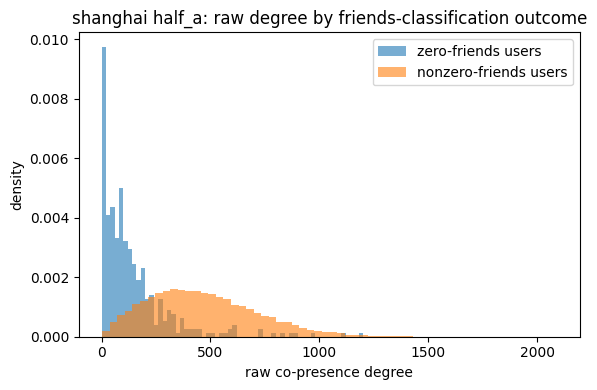

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(raw_a[zero_friends], bins=60, alpha=0.6, label="zero-friends users", density=True)
ax.hist(raw_a[~zero_friends], bins=60, alpha=0.6, label="nonzero-friends users", density=True)
ax.set_xlabel("raw co-presence degree")
ax.set_ylabel("density")
ax.set_title("shanghai half_a: raw degree by friends-classification outcome")
ax.legend()
fig.tight_layout()
fig.savefig("notebooks/08_recast_friendship_validation/outputs/check1_raw_degree_by_friends_outcome.pdf")
plt.show()

## Check 2: is the zero-friends pattern stable across independent real samples?

Run the exact same pipeline on `half_b` (the other real split used for the
`ref` baseline) and compare summary stats against `half_a`. If both halves
look similar, the zero-friends pattern is a stable property of how RECAST
reads this dataset -- not noise from one particular sample.

In [5]:
sp_b, loc_b, work_b = load_real("data/shanghai/shanghai_data_raw_half_b.parquet")
raw_b, friends_b, recast_b = friends_and_raw_degree(sp_b, loc_b, work_b)

rows = []
for label, friends in [("half_a", friends_a), ("half_b", friends_b)]:
    rows.append(
        {
            "split": label,
            "n_users": len(friends),
            "mean": round(float(friends.mean()), 2),
            "median": float(np.median(friends)),
            "p90": float(np.percentile(friends, 90)),
            "zero_frac_pct": round(100 * float((friends == 0).mean()), 1),
        }
    )
pl.DataFrame(rows)

split,n_users,mean,median,p90,zero_frac_pct
str,i64,f64,f64,f64,f64
"""half_a""",29251,101.63,88.0,203.0,1.3
"""half_b""",29251,101.12,88.0,201.0,1.2


## Conclusion (corrected)

**Check 1**: only **1.3%** of real users end up with zero classified friends
(390 of 29,251), and even those have real raw contacts (mean raw degree 141,
only 2 users truly have zero raw contacts). This is unremarkable -- not the
"half the population" artifact reported before the indexing fix.

**Check 2**: `half_a` and `half_b` produce closely matching friends-degree
distributions (see the table above) -- stable and reproducible.

**Corrected synthetic-vs-observed comparison** (shanghai `full_run1`):

| metric | synthetic | observed | ratio |
|---|---|---|---|
| mean degree | 19.15 | 101.63 | ~5.3x |
| mean clustering coefficient | 0.683 | 0.505 | ~1.35x |

RECAST-friends still meaningfully shrinks both gaps versus raw co-presence
(degree ~20x -> ~5.3x; clustering direction unchanged but less extreme), just
not as dramatically as the buggy first pass suggested. The over-clustering
finding (synthetic agents forming tighter cliques than real friend networks)
still holds directionally, just at ~1.35x rather than ~2.8x.